In [42]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV
import warnings
import tkinter as tk
from tkinter import filedialog, simpledialog

In [43]:
def extraer_datos_personalizados():
    num_carpetas = simpledialog.askinteger(
        "Cantidad de carpetas", 
        "¿Cuántas carpetas vas a seleccionar en total?", 
        minvalue=1, maxvalue=10
    )
    
    if not num_carpetas:
        return pd.DataFrame()

    datos_extraidos = []

    for i in range(num_carpetas):
        tipo_estrella = simpledialog.askstring(
            "Tipo de Estrella", 
            f"Carpeta {i+1} de {num_carpetas}:\n¿Qué tipo de estrella contiene? (Ej: F, G, K, M)"
        )
        
        if not tipo_estrella:
            return pd.DataFrame()
            
        tipo_estrella = tipo_estrella.upper().strip()
        directorio = filedialog.askdirectory(
            title=f"Selecciona la carpeta para los datos de estrellas {tipo_estrella}"
        )
        
        if not directorio:
            return pd.DataFrame()

        print(f"\nProcesando simulaciones en: {directorio} (Estrella {tipo_estrella})")
        planetas_encontrados = 0
        
        for raiz, dirs, archivos in os.walk(directorio):
            arch_readme = None
            arch_resumen = None
            
            for arch in archivos:
                if arch.startswith("README_") and arch.endswith(".txt"):
                    arch_readme = os.path.join(raiz, arch)
                if arch.endswith("_resumen.txt"):
                    arch_resumen = os.path.join(raiz, arch)

            if arch_readme and arch_resumen:
                carpeta_planeta = os.path.basename(raiz)
                carpeta_sistema = os.path.dirname(raiz) 
                
                subcarpetas = [d for d in os.listdir(carpeta_sistema) if os.path.isdir(os.path.join(carpeta_sistema, d))]
                num_planetas = len(subcarpetas)
                
                masa_tierra = None
                distancia_ua = None
                area_estable = None
                
                try:
                    with open(arch_readme, 'r', encoding='utf-8', errors='ignore') as f:
                        for linea in f:
                            if "Masa del Planeta" in linea:
                                val = linea.split(":")[-1].strip()
                                masa_tierra = float(re.search(r"[-+]?\d*\.\d+|\d+", val).group())
                            elif "Semi-eje mayor" in linea:
                                val = linea.split(":")[-1].strip()
                                distancia_ua = float(re.search(r"[-+]?\d*\.\d+|\d+", val).group())
                except Exception as e:
                    print(f"Error al leer README en {carpeta_planeta}: {e}")
                
                try:
                    with open(arch_resumen, 'r', encoding='utf-8', errors='ignore') as f:
                        for linea in f:
                            if linea.startswith("Área estable:"):
                                val_str = linea.split(":")[1].replace("km²", "").replace("km2", "").strip()
                                area_estable = float(val_str)
                except Exception as e:
                    print(f"Error al leer Resumen en {carpeta_planeta}: {e}")
                
                if masa_tierra is not None and distancia_ua is not None and area_estable is not None:
                    datos_extraidos.append({
                        "Sistema": os.path.basename(carpeta_sistema),
                        "Planeta": carpeta_planeta,
                        "Tipo_Estrella": tipo_estrella,
                        "Num_Planetas": num_planetas,
                        "Masa_Tierra": masa_tierra,
                        "Distancia_UA": distancia_ua,
                        "Area_Estable_km2": area_estable
                    })
                    planetas_encontrados += 1
                    
        print(f" -> Se extrajeron exitosamente los datos de {planetas_encontrados} planetas.")

    if datos_extraidos:
        df_consolidado = pd.DataFrame(datos_extraidos)
        print(f"\nExtracción finalizada. Total de planetas registrados: {len(df_consolidado)}")
        return df_consolidado
        
    return pd.DataFrame()

In [44]:
def _obtener_curva_convergencia(x, y, weights):
    xy_train = np.vstack([x, y]).T 
    bws = np.linspace(0.1, 1.5, 40)
    grid_params = {'bandwidth': bws}
    grid = GridSearchCV(KernelDensity(), grid_params, cv=3)
    try:
        grid.fit(xy_train, sample_weight=weights)
        return bws, grid.cv_results_['mean_test_score'], grid.best_estimator_.bandwidth
    except Exception:
        return bws, np.zeros_like(bws), 0.6

def plot_convergencia_bw(df: pd.DataFrame):
    metrica = "Area_Estable_km2"
    
    # Filtramos estrictamente valores > 0 para evitar errores matemáticos con el logaritmo
    mask_valid = (df[metrica] > 0) & (df["Distancia_UA"] > 0) & (df["Masa_Tierra"] > 0)
    df_valid = df[mask_valid].copy()
    
    df_filtrado = df_valid[df_valid['Num_Planetas'] >= 3]
    pnums = sorted(df_filtrado["Num_Planetas"].unique())
    num_paneles = len(pnums) + 1
    
    fig, axes = plt.subplots(1, num_paneles, figsize=(5 * num_paneles, 5.5), constrained_layout=True)
    fig.suptitle("KDE Bandwidth Optimization: Log-Likelihood Convergence", fontsize=18, fontweight="bold")
    
    if num_paneles == 1: 
        axes = [axes]
        
    def graficar_curva(ax, x_data, y_data, w_data, titulo, color):
        if len(x_data) <= 4:
            ax.set_title(titulo + f"\n(N={len(x_data)} - Insufficient Data)", fontsize=12)
            ax.axis('off')
            return
            
        print(f"Calculando {titulo}...")
        bws, puntajes, bw_optimo = _obtener_curva_convergencia(x_data, y_data, w_data)
        
        ax.plot(bws, puntajes, color=color, linewidth=2.5, label="Log-Likelihood")
        ax.scatter(bw_optimo, np.max(puntajes), color='red', s=80, zorder=5, edgecolor='black', label=f"Optimal Peak ({bw_optimo:.2f})")
        ax.axvline(x=bw_optimo, color='red', linestyle='--', alpha=0.6)
        
        ax.set_title(titulo + f" (N={len(x_data)})", fontsize=14, fontweight="bold")
        ax.set_xlabel("Bandwidth")
        if ax == axes[0]: ax.set_ylabel("Mean Log-Likelihood")
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.legend(loc='lower right', fontsize=10)

    # Usamos np.log10 directo ya que los ceros fueron filtrados por mask_valid
    x_glob = np.log10(df_valid["Distancia_UA"].values)
    y_glob = np.log10(df_valid["Masa_Tierra"].values)
    w_glob = np.log10(df_valid[metrica].values)
    graficar_curva(axes[0], x_glob, y_glob, w_glob, "Global View", "navy")
    
    colores = ["darkorange", "forestgreen", "purple", "crimson", "teal", "sienna"]
    for i, pnum in enumerate(pnums):
        df_sub = df_filtrado[df_filtrado["Num_Planetas"] == pnum]
        
        x_sub = np.log10(df_sub["Distancia_UA"].values)
        y_sub = np.log10(df_sub["Masa_Tierra"].values)
        w_sub = np.log10(df_sub[metrica].values)
        
        graficar_curva(axes[i+1], x_sub, y_sub, w_sub, f"{int(pnum)} Planets", colores[i % len(colores)])
        
    plt.show()

Iniciando escáner de simulaciones...

Procesando simulaciones en: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_F (Estrella F)
 -> Se extrajeron exitosamente los datos de 24 planetas.

Procesando simulaciones en: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_G (Estrella G)
 -> Se extrajeron exitosamente los datos de 121 planetas.

Procesando simulaciones en: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_K (Estrella K)
 -> Se extrajeron exitosamente los datos de 140 planetas.

Procesando simulaciones en: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_M (Estrella M)
 -> Se extrajeron exitosamente los datos de 160 planetas.

Extracción finalizada. Total de planetas registrados: 445

Generando gráficos de convergencia... Por favor espera.
Calculando Global View...
Calculando 3 Planets...
Calculando 4 Planets...
Calcul

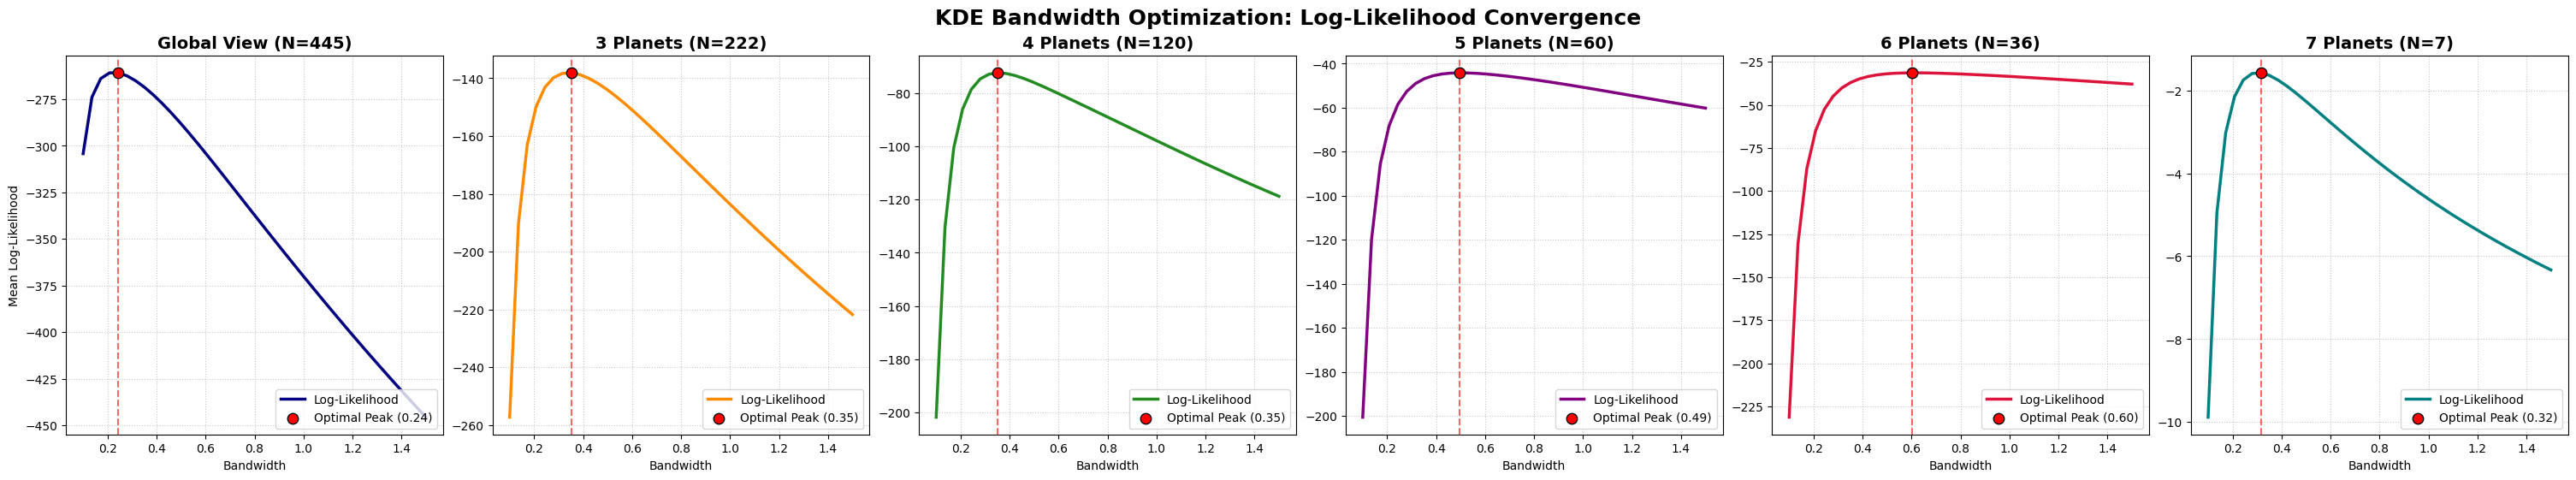

In [45]:
if __name__ == "__main__":
    root = tk.Tk()
    root.withdraw()
    print("Iniciando escáner de simulaciones...")
    
    df_datos = extraer_datos_personalizados()
    
    if not df_datos.empty:
        print("\nGenerando gráficos de convergencia... Por favor espera.")
        plot_convergencia_bw(df_datos)
    else:
        print("\nNo hay datos para graficar. El proceso terminó.")

C:\Users\darkm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\model_selection\_search.py:881: UserWarning: The scoring <class 'sklearn.neighbors._kde.KernelDensity'>.score does not support sample_weight, which may lead to statistically incorrect results when fitting GridSearchCV(cv=3, estimator=KernelDensity(),
             param_grid={'bandwidth': array([0.1       , 0.13589744, 0.17179487, 0.20769231, 0.24358974,
       0.27948718, 0.31538462, 0.35128205, 0.38717949, 0.42307692,
       0.45897436, 0.49487179, 0.53076923, 0.56666667, 0.6025641 ,
       0.63846154, 0.67435897, 0.71025641, 0.74615385, 0.78205128,
       0.81794872, 0.85384615, 0.88974359, 0.92564103, 0.96153846,
       0.9974359 , 1.03333333, 1.06923077, 1.10512821, 1.14102564,
       1.17692308, 1.21282051, 1.24871795, 1.28461538, 1.32051282,
       1.35641026, 1.39230769, 1.42820513, 1.46410256, 1.5       ])}) with sample_weight. 
  wa

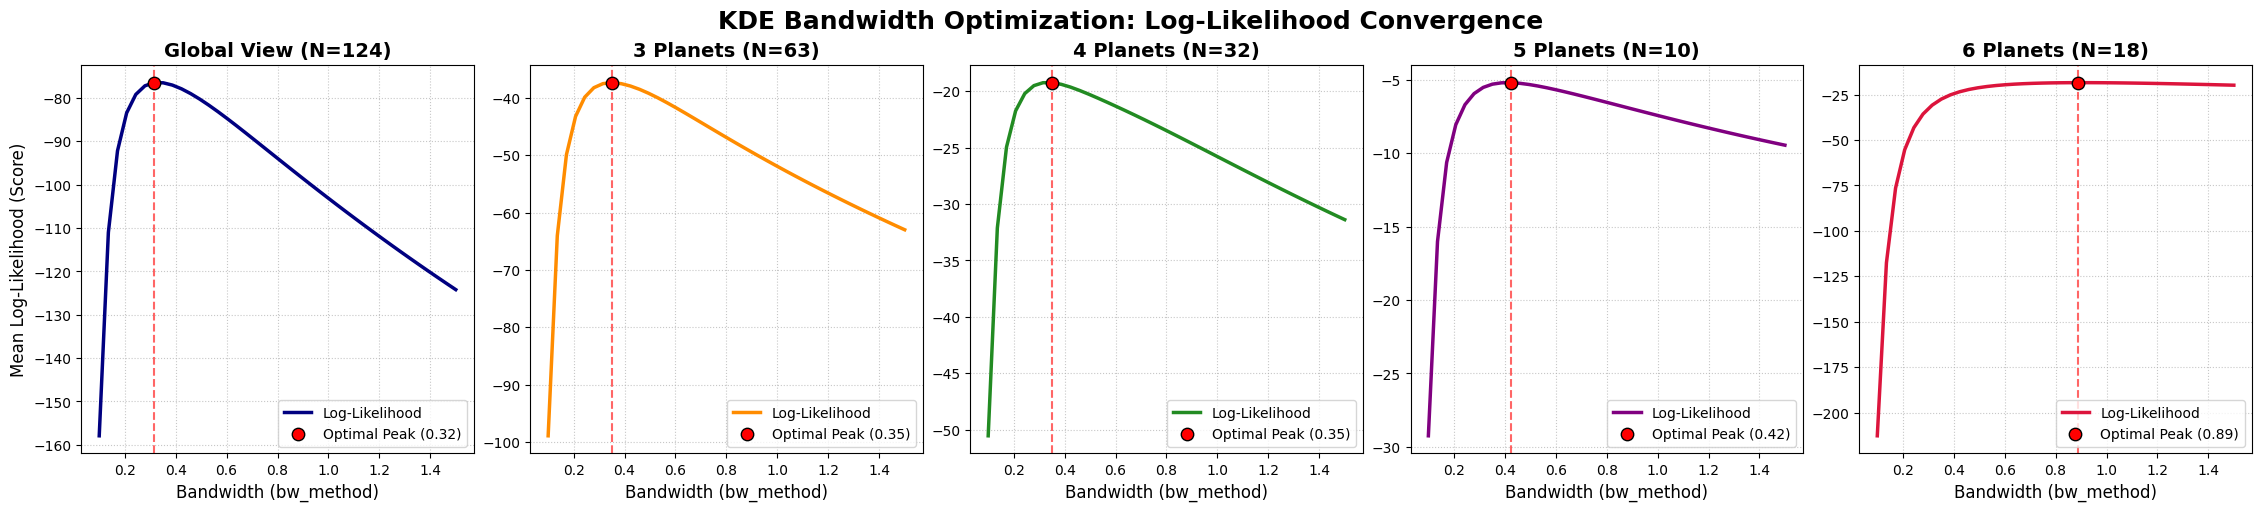

In [12]:
if __name__ == "__main__":
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)

    DIRECTORIO_RAIZ = filedialog.askdirectory(title="Selecciona la carpeta raíz")

    if DIRECTORIO_RAIZ:
        # AQUÍ: Llama a tu función real de extracción de datos
        # df_datos = extraer_datos_de_carpetas(DIRECTORIO_RAIZ)
        
        # Asegúrate de reemplazar esto con tu DataFrame real
        if 'df_datos' in locals() and not df_datos.empty:
            plot_convergencia_bw(df_datos)
        else:
            print("Asegúrate de conectar tu función 'extraer_datos_de_carpetas' en el código.")